## Imports

In [48]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset and define Theme

In [49]:
sns.set_theme(style="whitegrid")

df = pd.read_json('./dataset_quality.jsonl', lines=True)
print(df.shape)
df.head()

(6, 7)


,before,after,refactor_type,repo,commit_sha,file,diff_lines
0,def format_rq_status(rq_status: Optional[dict]...,def format_rq_status(rq_status: Optional[dict]...,deduplicate,rtCamp/Frappe-Manager,451425b58771ba32afcf394558dbc9e962ea60e0,Docker/frappe/fmx/fmx/supervisor/status_format...,22
1,def _display_stop_results_by_service(results: ...,def _display_stop_results_by_service(results: ...,deduplicate,rtCamp/Frappe-Manager,ea6a7bba31bd77110bb1a0091c109c3b50f1b322,Docker/frappe/fmx/fmx/cli.py,54
2,def _handle_restart_results(results: dict):\n ...,def _handle_restart_results(results: dict):\n ...,general,rtCamp/Frappe-Manager,ea6a7bba31bd77110bb1a0091c109c3b50f1b322,Docker/frappe/fmx/fmx/cli.py,26
3,"def command(\n ctx: typer.Context,\n ser...","def command(\n ctx: typer.Context,\n ser...",deduplicate,rtCamp/Frappe-Manager,ea6a7bba31bd77110bb1a0091c109c3b50f1b322,Docker/frappe/fmx/fmx/commands/stop.py,23
4,"def signal_service(\n service_name: str,\n ...","def signal_service(service_name: str, signal_n...",general,rtCamp/Frappe-Manager,ea6a7bba31bd77110bb1a0091c109c3b50f1b322,Docker/frappe/fmx/fmx/supervisor/api.py,23


## Quality Metrics

# Chars
- `before_chars`: length of snippet before refactoring
- `after_chars`: length of snippet before refactoring
- `chars_delta`: number of changed chars
- `chars_delta_abs`: absolute value of `char_delta`

# Lines
- `before_lines`: Number of lines before refactor
- `after_lines`: Number of lines after refactor
- `lines_delta`: Number of changed lines
- `lines_delta_abs`: absolute value of `lines_delta`

In [50]:
df["before_chars"] = df["before"].str.len()
df["after_chars"] = df["after"].str.len()
df["chars_delta"] = df["after_chars"] - df["before_chars"]
df["chars_delta_abs"] = df["chars_delta"].abs()

df["lines_before"] = df["before"].str.count("\n") + 1
df["lines_after"] = df["after"].str.count("\n") + 1
df["lines_delta"] = df["lines_after"] - df["lines_before"]
df["lines_delta_abs"] = df["lines_delta"].abs()

print(df[["diff_lines", "before_chars", "after_chars", "chars_delta", "lines_before", "lines_after", "lines_delta", "lines_delta_abs"]].describe())


       diff_lines  before_chars  after_chars  chars_delta  lines_before  \
count    6.000000      6.000000     6.000000     6.000000      6.000000   
mean    27.333333   1909.000000  1905.333333    -3.666667     43.833333   
std     13.470956    904.396152   514.934429   454.000294     21.008728   
min     16.000000    292.000000   906.000000  -795.000000      5.000000   
25%     22.250000   1834.250000  1935.750000   -29.000000     39.500000   
50%     23.000000   2019.000000  2015.000000    46.500000     50.500000   
75%     25.250000   2236.000000  2191.750000   101.750000     58.500000   
max     54.000000   3043.000000  2336.000000   614.000000     60.000000   

       lines_after  lines_delta  lines_delta_abs  
count     6.000000     6.000000         6.000000  
mean     46.833333     3.000000         6.666667  
std      13.688194     9.380832         6.742897  
min      23.000000   -10.000000         1.000000  
25%      43.750000    -0.500000         1.250000  
50%      47.500000

## Histogram

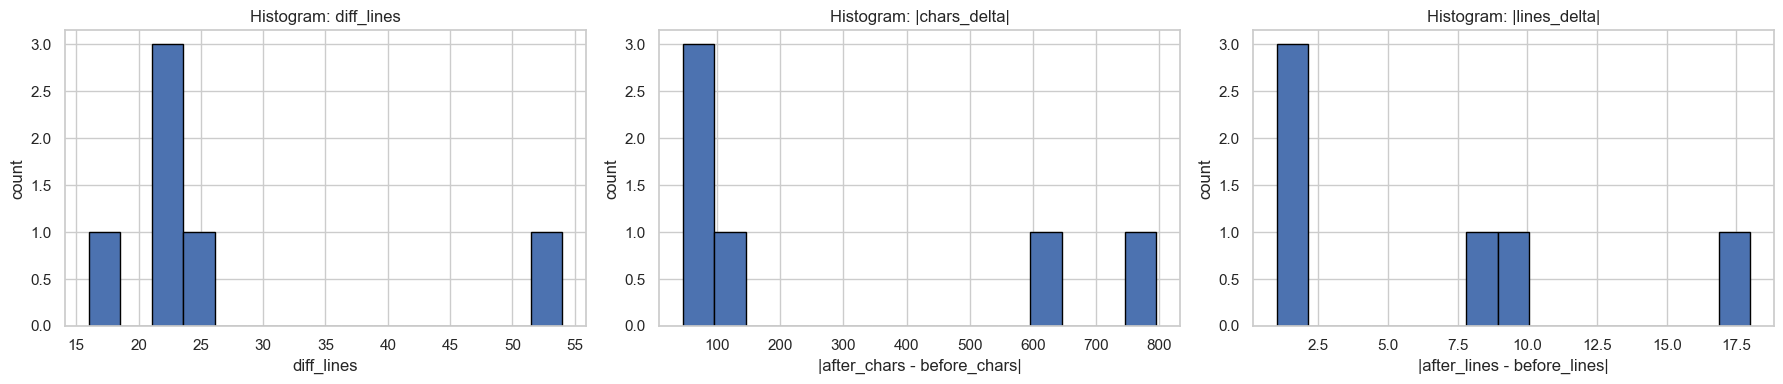

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df["diff_lines"], bins=15, edgecolor="black")
axes[0].set_title("Histogram: diff_lines")
axes[0].set_xlabel("diff_lines")
axes[0].set_ylabel("count")

axes[1].hist(df["chars_delta_abs"], bins=15, edgecolor="black")
axes[1].set_title("Histogram: |chars_delta|")
axes[1].set_xlabel("|after_chars - before_chars|")
axes[1].set_ylabel("count")

axes[2].hist(df["lines_delta_abs"], bins=15, edgecolor="black")
axes[2].set_title("Histogram: |lines_delta|")
axes[2].set_xlabel("|after_lines - before_lines|")
axes[2].set_ylabel("count")

plt.tight_layout()
plt.show()